## 1. Configuración Inicial y Cargue de Datos

In [1]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Almacenar en cache los resultados de funciones en el disco
# ==============================================================================
import joblib

# Gestion de librerias
# ==============================================================================
from importlib import reload

# Preparacion de datos
# ==============================================================================
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split

# Graficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Interactuar con os y solicitudes desde HTTP
# ==============================================================================
import os
import sys
import requests

# Configuracion warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Parametros globales
# ==============================================================================

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/Smartdvis17/Churn/master/'

# Nombres de los archivos requeridos
DATASET_FILE_NAME = 'df_consolidado.parquet'
UTILS_FILE_NAME = 'funciones.py'

# Nombres de los directorios para utilidades, datasets y modelos
DATASETS_PATH = 'datasets/'
UTILS_PATH = 'utils/'
MODELS_PATH = 'modelos/'
MODELS_CLASIFICACION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH = os.path.join(MODELS_PATH, 'scaler')

# URL completa del dataset y utils en GitHub
github_dataset_url = GITHUB_BASE_URL + DATASET_FILE_NAME
github_utils_url = GITHUB_BASE_URL + UTILS_FILE_NAME

# Rutas locales completas de datasets y utils
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path = os.path.join(UTILS_PATH, UTILS_FILE_NAME)

In [3]:
# Funcion local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.

    Args:
        url (str): URL del archivo
        path (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f"Descargando {description} desde: {url}")

    # Realiza una solicitud HTTP GET a la URL proporcionada
    response = requests.get(url)

    # Lanza una excepción si la descarga falla (código de estado HTTP no 200)
    response.raise_for_status()

    # Abre el archivo local en modo de escritura binaria ('wb')
    with open(path, 'wb') as f:
        # Escribe el contenido binario de la respuesta HTTP en el archivo local
        f.write(response.content)

    # Imprime un mensaje confirmando que la descarga fue exitosa y la ruta de guardado
    print(f"{description} descargado exitosamente a: {path}")

In [4]:
## Configuración entorno Colab
# ==============================================================================

# Creación de directorios locales
os.makedirs(DATASETS_PATH, exist_ok=True)
os.makedirs(UTILS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# Crear subdirectorios específicos para modelos y escalados
os.makedirs(MODELS_CLASIFICACION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH, exist_ok=True)

# # Descarga de archivos
# download_file(github_dataset_url, local_dataset_path, "dataset")
# download_file(github_utils_url, local_utils_path, "funciones")

df = pd.read_parquet(local_dataset_path)   # o read_csv / read_excel según tu caso
print(f"Dataset cargado: {df.shape}")

Dataset cargado: (444816, 40)


## 2. Funciones Auxiliares

In [5]:
## Funciones externas
# ==============================================================================

## Añade la ruta definida en 'UTILS_PATH' al 'sys.path' para que Python pueda encontrar módulos
sys.path.append(UTILS_PATH)

## Importa Funciones externas
from funciones import multiple_plot

## 3. Carga e Inspección Inicial de Datos

In [6]:
#Cargar el dataset
df = pd.read_parquet(local_dataset_path)

In [7]:
#Previsualización de los datos
df.head()

,CANAL,Nit entidad,CEDULA,GRUPAL,Entidad,Producto,CONTRATO,COD_FORMA_PAGO,ESTADO_C,RENOVACION,...,TOTAL_PRIMA_MASCOTAS,ESTADO_ACTUAL,PFI,TOTAL_PRIMA,VALOR_RENOVACION,TOTAL_TITULARES,TOTAL_PERSONAS,TIENE PFI ACTUALMENTE?,fecha_mes,Telefono mas efectivo
0,Sedes Alternas,800108302-06,70100976,326,INDIVIDUALES MEDELLIN,Individuales Medellín - PFI PLUS,00000212,30,R,2026-08-15,...,0.0,Activo,1,52050.0,52050.0,1,10,SI,2026-05-01,3147349612
1,Sedes Alternas,800108302-06,32532070,326,INDIVIDUALES MEDELLIN,Individuales Medellín - PFI PLUS,00030545,360,R,2026-08-04,...,0.0,Activo,1,20200.0,242400.0,1,2,SI,2026-05-01,0
2,Asociadas,890981395,3628971,12,CONFIAR COOPERATIVA FINANCIERA,Confiar - Previsión,00048177,360,R,2026-06-28,...,13000.0,Activo,0,31900.0,382800.0,1,6,NO,2026-05-01,6044877063
3,Asociadas,890981395,43678255,12,CONFIAR COOPERATIVA FINANCIERA,Confiar - Previsión,00048226,360,R,2026-10-13,...,0.0,Activo,0,9500.0,114000.0,1,2,NO,2026-05-01,3113493755
4,Asociadas,890981395,71875111,12,CONFIAR COOPERATIVA FINANCIERA,Confiar - Previsión,00039494,360,R,2026-10-26,...,0.0,Activo,0,9500.0,114000.0,1,2,NO,2026-05-01,3136647444


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 444816 entries, 0 to 444815
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   CANAL                      444816 non-null  str           
 1   Nit entidad                444816 non-null  str           
 2   CEDULA                     444504 non-null  str           
 3   GRUPAL                     444816 non-null  str           
 4   Entidad                    444816 non-null  str           
 5   Producto                   444816 non-null  str           
 6   CONTRATO                   444816 non-null  str           
 7   COD_FORMA_PAGO             444816 non-null  int64         
 8   ESTADO_C                   444816 non-null  str           
 9   RENOVACION                 444816 non-null  datetime64[ns]
 10  genero                     302214 non-null  str           
 11  MECANISMO_PAGO             444356 non-null  str           
 12 

## 4. Limpieza de datos (Data Cleaning)

### Tratamiento de nulos en Churn Category y Churn Reason

En la revisión del dataset encontramos valores nulos en estas dos variables, sin embargo luego de revisar el dataset y analizar los datos identificamos que estos datos nulos obedecen a que estas variables solo son diligenciadas para aquellos que abandonan, sin embargo como el objetivo es predecir el abandono estas variables no aportan información que contribuya a la prediccion de abandono y podrian generar confusiones en nuestros modelos de tal manera que decidimos eliminarlas del conjunto de datos.

In [ ]:
# Eliminamos las columnas 'Churn Category' y 'Churn Reason' del DataFrame
df = df.drop(['Churn Category', 'Churn Reason'], axis=1)

In [ ]:
# Eliminamos las columnas 'Country', 'City', 'State', 'Under 30', 'Dependents', y 'Quarter' del DataFrame, ya que no aportan información relevante para el análisis y modelado.
df = df.drop(['Customer ID','City','Country', 'State', 'Under 30','Dependents', 'Quarter'], axis=1)
df.head(2)

## 5. Visualización de datos

### Variables de entrada

In [9]:
#Listamos las variables categóricas
catCols = df.select_dtypes(include = ["object", 'category']).columns.tolist()

df[catCols].head(2)

,CANAL,Nit entidad,CEDULA,GRUPAL,Entidad,Producto,CONTRATO,ESTADO_C,genero,MECANISMO_PAGO,MUNICIPIO,FECHA_CANCELACION,MOTIVO_CANCELACION,ESTADO_ACTUAL,TIENE PFI ACTUALMENTE?,Telefono mas efectivo
0,Sedes Alternas,800108302-06,70100976,326,INDIVIDUALES MEDELLIN,Individuales Medellín - PFI PLUS,00000212,R,M,Pago en Caja,Medellín,None,NaN,Activo,SI,3147349612
1,Sedes Alternas,800108302-06,32532070,326,INDIVIDUALES MEDELLIN,Individuales Medellín - PFI PLUS,00030545,R,F,Pago en Caja,Medellín,None,NaN,Activo,SI,0


In [10]:
#Listamos las variables numéricas

numCols=df.select_dtypes(include = ['float64','int32','int64']).columns.tolist()
df[numCols].head()

,COD_FORMA_PAGO,EDAD_TT,ANTIGUEDAD_ANOS,TOTAL_PERSONAS_PROTEGIDOS,PROTEGIDOS_MENORES_65,PROTEGIDOS_MAYORES_65,TOTAL_MASCOTAS,EXEQUIAS_PERSONAS,AUXILIOS_PERSONAS,ASISTENCIAS_PERSONAS,...,ASISTENCIAS_MASCOTAS,TOTAL_PERSONAS_FALLECIDAS,TOTAL_MASCOTAS_FALLECIDAS,TOTAL_PRIMA_PERSONAS,TOTAL_PRIMA_MASCOTAS,PFI,TOTAL_PRIMA,VALOR_RENOVACION,TOTAL_TITULARES,TOTAL_PERSONAS
0,30,68,18.78,11,10.0,0.0,0,11,1,2,...,0,1,0,52050.0,0.0,1,52050.0,52050.0,1,10
1,360,69,16.16,3,2.0,0.0,0,3,1,2,...,0,0,0,20200.0,0.0,1,20200.0,242400.0,1,2
2,360,72,13.91,7,7.0,0.0,2,7,0,0,...,0,0,1,18900.0,13000.0,0,31900.0,382800.0,1,6
3,360,56,13.62,3,2.0,0.0,0,2,1,0,...,0,0,0,9500.0,0.0,0,9500.0,114000.0,1,2
4,360,64,14.59,3,2.0,0.0,0,2,1,0,...,0,0,0,9500.0,0.0,0,9500.0,114000.0,1,2


In [ ]:
#Visualización de frecuencia de instancias para variables categóricas
multiple_plot(3, df , catCols, None, 'countplot', 'Frecuencia de instancias para variables categóricas',30)

In [11]:
# Distribución de cada variable categórica en el conjunto de datos

for col in catCols:
    print("="*5 + f" {col} " + "="*20)
    print(df[col].value_counts())
    print()

===== CANAL ====================
CANAL
Asociadas                  307069
Corporativo                 86799
Sedes Alternas              27045
Sedes Alternas Apartadó     23903
Name: count, dtype: int64

===== Nit entidad ====================
Nit entidad
890981395       62861
811022688       42104
890910087       36605
890904478       24343
800108302-06    19393
                ...  
800002845           1
900736726           1
800108302-25        1
900359246           1
900671824           1
Name: count, Length: 392, dtype: int64

===== CEDULA ====================
CEDULA
123           40
999999        16
24813475       8
43923633       8
1000397285     7
              ..
70103384       1
43758829       1
1038814846     1
1001477563     1
71388177       1
Name: count, Length: 375166, dtype: int64

===== GRUPAL ====================
GRUPAL
12     62796
30     42103
504    27341
326    19393
283    15845
       ...  
779        1
804        1
400        1
644        1
823        1
Name: coun

In [ ]:
#Visualización de variables numéricas con respecto al precio
multiple_plot(1, df , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)

### Variable de salida

In [12]:
df.groupby('ESTADO_ACTUAL')['ESTADO_ACTUAL'].count().sort_values(ascending=False)

ESTADO_ACTUAL
Activo       310744
Cancelado    134072
Name: ESTADO_ACTUAL, dtype: int64

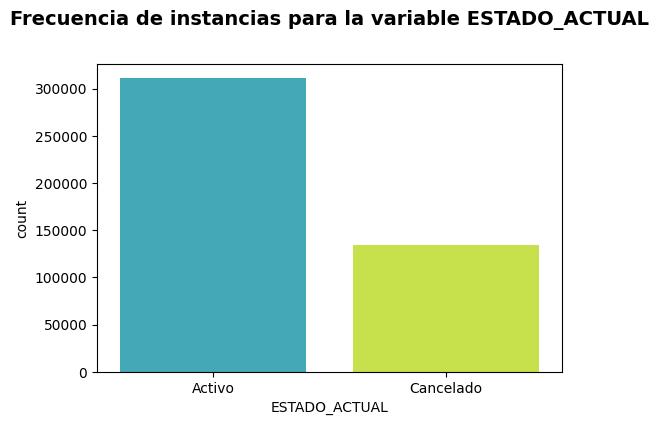

In [14]:
multiple_plot(1, df , None, 'ESTADO_ACTUAL', 'countplot', 'Frecuencia de instancias para la variable ESTADO_ACTUAL',0)

## 6. Preparación de Datos para el Modelado

### Imputaciones

Realizamos la validacion para identificar valores nulos o vacios dentro de las diferentes variables numericas y categoricas.

In [15]:
# identificación de valores nulos para las variables categóricas
for col in catCols:
    n_nulos = np.sum(pd.isnull(df[col]))
    if n_nulos > 0:
        print(col, n_nulos)

CEDULA 312
genero 142602
MECANISMO_PAGO 460
MUNICIPIO 551
FECHA_CANCELACION 295596
MOTIVO_CANCELACION 295596


In [16]:
#Identificación de valores nulos para las variables numéricas
for col in df[numCols]:
    print (col, np.sum(pd.isnull(df[col])))

COD_FORMA_PAGO 0
EDAD_TT 0
ANTIGUEDAD_ANOS 0
TOTAL_PERSONAS_PROTEGIDOS 0
PROTEGIDOS_MENORES_65 253290
PROTEGIDOS_MAYORES_65 253290
TOTAL_MASCOTAS 0
EXEQUIAS_PERSONAS 0
AUXILIOS_PERSONAS 0
ASISTENCIAS_PERSONAS 0
EXEQUIAS_MASCOTAS 0
ASISTENCIAS_MASCOTAS 0
TOTAL_PERSONAS_FALLECIDAS 0
TOTAL_MASCOTAS_FALLECIDAS 0
TOTAL_PRIMA_PERSONAS 0
TOTAL_PRIMA_MASCOTAS 0
PFI 0
TOTAL_PRIMA 0
VALOR_RENOVACION 0
TOTAL_TITULARES 0
TOTAL_PERSONAS 0


In [ ]:
# Registros donde varias características (Offer, Internet Type, ) son vacías
df[df['Offer'].isna() | df['Internet Type'].isna()][['Offer', 'Internet Type']].head(20)

In [ ]:
df.Offer.unique()

In [ ]:
# Reemplazamos los valores NaN en la columna 'Offer' por 'No offer'
df['Offer'] = df['Offer'].fillna('No offer')

df['Offer'].unique()

In [ ]:
# Reemplazamos los valores NaN en la columna 'Internet Type' por 'No internet'
df['Internet Type'] = df['Internet Type'].fillna('No internet')

df['Internet Type'].unique()

Al realizar la revision de datos nulos o vacios identificamos que en las variables numericas no se tienen datos vacios por lo que no se realiza ningun imputación, sin embargo al revisar las variables categoricas identificamos datos `nan`, sin embargo estos no obedecen a una inconsistencia en el dataset o falta del dato si no al comportamiento mismo, se identifican valores `nan` en `Offer` para aquellas personas que no tienen una oferta activa por lo que lo imputamos con `No offer`, asi mismo sucede para `Internet Type` que figura nan para aquellas personas que no tienen el servicio contratado asi que lo imputamos con `No internet`.

## 7. División y Exportación Manual del Dataset

Se realiza una división manual del DataFrame `df` (después de todas las etapas de limpieza y tratamiento de nulos/outliers) en dos partes.

In [17]:
# Porcentaje de filas para la primera parte (por ejemplo, 90%)
percentage_first_part = 0.90

# Número de filas para la primera parte
n_rows_part1 = int(len(df) * percentage_first_part)

# Obtener índices aleatorios para la primer parte
indices_part1 = df.sample(n=n_rows_part1, random_state=123).index

# Obtener índices para la segunda parte (resto de las filas)
indices_part2 = df.index.difference(indices_part1)

# Dividir el DataFrame en dos partes
dfc = df.loc[indices_part1]
dfp = df.loc[indices_part2]

In [18]:
dfc.shape

(400334, 40)

### Deteccion de valores atipicos para variables

Se aplica LOF sobre las variables numéricas del dataset para identificar registros con combinaciones inusuales de valores. Se excluye únicamente CLTV porque es un valor calculado a partir de los ingresos del cliente.


In [ ]:
# Se excluyen variables geográficas (Zip Code, Latitude, Longitude CLTV)
# porque no representan comportamiento de negocio y distorsionan la detección multivariada

exclude_from_lof = ['Zip Code', 'Latitude', 'Longitude', 'CLTV']
feature_cols = [col for col in numCols if col not in exclude_from_lof]

print(f"Variables usadas en LOF ({len(feature_cols)}): {feature_cols}")

# contamination='auto' usa la heurística del paper original (más conservador que fijar 0.1)
lof = LocalOutlierFactor(n_neighbors=13, contamination='auto')

# Ajustar y predecir sobre el espacio de features de entrada
y_pred = lof.fit_predict(dfc[feature_cols])

# Identificar los índices de los valores atípicos
outliers = y_pred == -1

print(f'\nTotal outliers detectados: {outliers.sum()}')
print('Indices de valores atípicos: ', dfc[outliers].index.tolist())

In [ ]:
# Eliminar los valores atípicos y reiniciar el índice
dfc = dfc.loc[~outliers].reset_index(drop=True)

In [ ]:
dfc.shape

In [ ]:
multiple_plot(1, dfc , None, 'Churn Label', 'countplot', 'Frecuencia de instancias para la variable Churn Label',0)

In [ ]:
dfc.groupby('Churn Label')['Churn Label'].count().sort_values(ascending=False)

## 8. Exportar el dataset

In [ ]:
# Exportamos el dataframe a un archivo CSV
dfc.to_csv(DATASETS_PATH + 'cancelados_Prep.csv', index=False)
dfp.to_csv(DATASETS_PATH + 'cancelado_Prue.csv', index=False)